# Modelado de Regresión Lineal Múltiple — Tendencias de YouTube (EE. UU.)

Notebook cual documenta la fase de modelado del proyecto, utilizando el conjunto de datos previamente procesado y estructurado(`USvideos_clean.csv`), 

## Variables Utilizadas
* **Target (y):** `log_likes` (Logaritmo de los likes).
    Transformación logarítmica de la cantidad total de "Me gusta". Se utiliza esta representación matemática para estabilizar la varianza y normalizar la distribución de los datos virales.
* **Predictoras (X):**
  * *Transformaciones logarítmicas:* `log_views` (Métrica de volumen de base), `log_dislikes`, `log_comments`, `log_days_to_trend` (Días hasta volverse tendencia)
  * *Ratios:* `dislike_view_ratio`, `comment_view_ratio` (Proporciones de interacción que evitan la redundancia con el volumen crudo)
  * *Texto y temporales:* `title_length`, `n_tags`, `first_trend`, `desc_faltante`
  * *Categorías (One-Hot):* `catgrupo_MedioBajo`, `catgrupo_MedioAlto`, `catgrupo_Alto`
  * *Opcionales:* `ratings_disabled`

## 1. Setup y definición de variables

Importamos las librerías necesarias para la elaboración del modelamiento, cargamos los datos del conjunto de datos mencionado, preparamos nuestras variables predictoras ($X$) y nuestra variable objetivo ($Y$). 

Para garantizar la integridad matemática del modelo de Regresión Lineal, hemos separado nuestras variables predictoras en dos listas distintas:
1. **Numéricas:** Variables continuas que requieren estandarización (ej. ratios, transformaciones logarítmicas).
2. **Binarias:** Variables categóricas codificadas (One-Hot, booleanas) que **no** deben ser alteradas para mantener su interpretabilidad (0 y 1).

In [67]:
# 1.1 Importación de librerías 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# 1.2 Carga de datos
df = pd.read_csv('../dataset/USvideos_clean.csv')
print(f"Dimensiones: {df.shape}")
display(df.head())


# 1.3 Definición de variables: Es necesario la separación de variables seleccionadas 
# en dos listas para escalar solo las columnas numéricas
cat_numericas = [
    "log_views", "log_dislikes", "log_comments",
    "dislike_view_ratio", "comment_view_ratio", 
    "log_days_to_trend", 
    "title_length", 
    "n_tags"
]
cat_binarias = [
    "first_trend", 
    "desc_faltante",
    "catgrupo_MedioBajo", 
    "catgrupo_MedioAlto", 
    "catgrupo_Alto", 
    "ratings_disabled"
]

Dimensiones: (40899, 29)


,video_id,trending_date,likes,log_likes,views,dislikes,comment_count,days_to_trend,views_cap,dislikes_cap,...,n_tags,first_trend,desc_faltante,category_name,cat_grupo,catgrupo_MedioBajo,catgrupo_MedioAlto,catgrupo_Alto,comments_disabled,ratings_disabled
0,2kyS6SvSYSE,2017-11-14,57527,10.960027,748374,2966,15954,1,748374.0,2966.0,...,1,True,False,People & Blogs,MedioAlto,0,1,0,False,False
1,1ZAPwfrtAFY,2017-11-14,97185,11.484382,2418783,6146,12703,1,2418783.0,6146.0,...,4,True,False,Entertainment,MedioAlto,0,1,0,False,False
2,5qpjK5DgCt4,2017-11-14,146033,11.891595,3191434,5339,8181,2,3191434.0,5339.0,...,23,True,False,Comedy,Alto,0,0,1,False,False
3,puqaWrEC7tY,2017-11-14,10172,9.227492,343168,666,2146,1,343168.0,666.0,...,27,True,False,Entertainment,MedioAlto,0,1,0,False,False
4,d380meD0W0M,2017-11-14,132235,11.792343,2095731,1989,17518,2,2095731.0,1989.0,...,14,True,False,Entertainment,MedioAlto,0,1,0,False,False


## 2: División de Datos y Estandarización Segura

Dividimos el conjunto de datos en **80% para entrenamiento** y **20% para pruebas**. De esta manera, evitamos un posible caso de *overfitting* (sobreajuste del modelo). 

**Prevención de Data Leakage:**
Aplicamos escalamiento estadístico y ajustamos las métricas de estandarización *únicamente* sobre nuestro conjunto de entrenamiento. De esta forma, garantizamos que la evaluación final del modelo no sea un resultado de memorización. 

In [68]:
# 2.1  Definición de target (Y) y features (X) seleccionados
X = df[cat_numericas + cat_binarias]
y = df["log_likes"]

#2.2 Partición de Datos  ( Train:80%, Test:20% )
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

#2.3 Clonación de columnas numéricas: Es necesario asegurar la compatibilidad de las variables al momento de proceder
# con la estandarización selectiva. Por esta razón forzamos las variables numéricas a 'float'. 
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cat_numericas] = X_train_scaled[cat_numericas].astype(float)
X_test_scaled[cat_numericas] = X_test_scaled[cat_numericas].astype(float)

# 2.4 Estandarización de variables numéricas 
train_num_scaled = scaler.fit_transform(X_train[cat_numericas].to_numpy())
test_num_scaled = scaler.transform(X_test[cat_numericas].to_numpy())

# 2.5 Actualización de las columnas procesadas
X_train_scaled.loc[:, cat_numericas] = train_num_scaled
X_test_scaled.loc[:, cat_numericas] = test_num_scaled

## 3: Entrenamiento del Modelo y Evaluación de Métricas

Por consiguiente, teniendo los datos ya estructurados, construimos el modelo de **Regresión Lineal Múltiple** y lo entrenamos. 

Después, calculamos las predicciones sobre el conjunto seleccionado para las prueba y evaluamos el rendimiento mediante las siguientes métricas:
* **$R^2$ - Coeficiente de Determinación:** Mide el porcentaje de la varianza de los likes que el modelo es capaz de explicar.
* **RMSE - Raíz del Error Cuadrático Medio:** Mide el error promedio en la aplicación del modelo. 

In [69]:
# 3.1 Preparación 
X_train_np = X_train_scaled.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = X_test_scaled.to_numpy()
y_test_np = y_test.to_numpy()

# 3.2 Instanciación del modelo predictivo
model = LinearRegression()

# 3.3 Entrenamiento
model.fit(X_train_np, y_train_np)

#3.4 Evaluación de Métricas de negocio 
y_pred_np = model.predict(X_test_np)
rmse_log = np.sqrt(mean_squared_error(y_test_np, y_pred_np))
r2 = r2_score(y_test_np, y_pred_np)

print(f"Resultados del Modelo:")
print(f"- Coeficiente de Determinación (R²): {r2:.4f}")

y_test_real = np.expm1(y_test_np)
y_pred_real = np.expm1(y_pred_np)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"- RMSE: {rmse_real:,.0f} likes de diferencia promedio")

Resultados del Modelo:
- Coeficiente de Determinación (R²): 0.8918
- RMSE: 135,040 likes de diferencia promedio


## 4. Visualización

Para poder interpretar visualmente el desempeño del modelo, graficamos un gráfico de dispersión que compara los valores reales obtenidos en YouTube con las predicciones generadas por el algoritmo. 

La linea diagonal observada a través del gráfico representa la predicción del modelo.

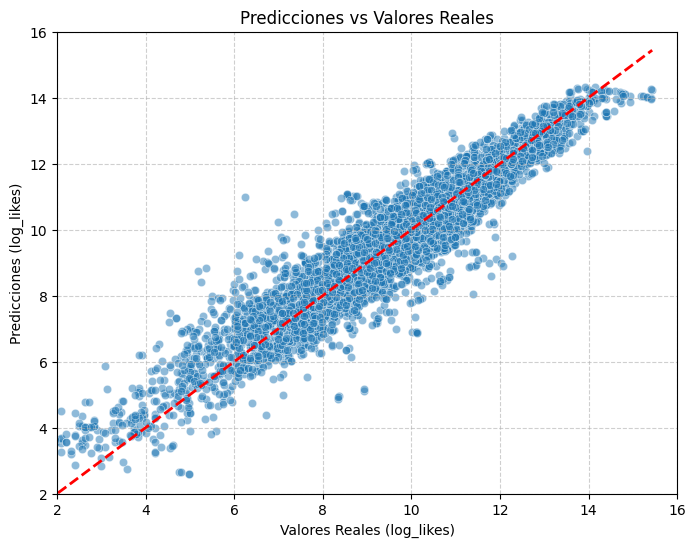

In [70]:
# 4.1 Desarrollo del gráfico
plt.figure(figsize=(8, 6))
plt.scatter(y_test_np, y_pred_np, alpha=0.5, edgecolor='w', linewidth=0.5)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', lw=2)

plt.xlim(2, 16)  
plt.ylim(2, 16)  

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Valores Reales (log_likes)')
plt.ylabel('Predicciones (log_likes)')
plt.title('Predicciones vs Valores Reales')
plt.show()

## 5. Interpretación de Coeficientes

En este último paso, extraemos los pesos (coeficientes) que el algoritmo asignó a cada `feature` para identificar qué factores impactan en la viralidad de un video.

* **Coeficientes positivos:** Indican que la característica impulsa la viralidad; a mayor valor de la variable, se predice un incremento en la cantidad de `likes`.
* **Coeficientes negativos:** Indican que la característica reduce la viralidad; a mayor valor de la variable, se predice una disminución en la cantidad de `likes`.


In [ ]:
coeficientes = pd.DataFrame({
    'Variable': cat_numericas + cat_binarias,
    'Coeficiente': model.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("Impacto de las variables en la predicción de log_likes:")
display(coeficientes)

Impacto de las variables en la predicción de log_likes (Modelo Optimizado):


,Variable,Coeficiente
12,catgrupo_Alto,1.141321
0,log_views,1.029724
11,catgrupo_MedioAlto,0.879518
2,log_comments,0.595614
10,catgrupo_MedioBajo,0.288463
1,log_dislikes,0.283184
4,comment_view_ratio,0.101447
7,n_tags,0.006893
8,first_trend,0.005726
5,log_days_to_trend,-0.072070
